In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sql_functions import read_query

In [ ]:
#import sys
#!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [2]:
query ="select * from customers limit 5"
read_query(query)

,CustomerID,FirstName,LastName,Email,Phone,Address,State
0,C-2023-100-1,Mahika,Sunder,MahikaSunder_11@zmail.com,03412176590,"H.No. 155, Chana",Assam
1,C-2023-100-10,Zeeshan,Vasa,ZeeshanVasa_1@zmail.com,+911151051656,"52, Roy Nagar",Tripura
2,C-2023-100-100,Aaina,Sachdeva,AainaSachdeva_9@zmail.com,+918834507719,"75/92, Kade Marg",Nagaland
3,C-2023-100-101,Shray,Bajwa,ShrayBajwa_11@zmail.com,07410498662,"45, Bora Ganj",Manipur
4,C-2023-100-102,Navya,Dash,NavyaDash_5@zmail.com,+917644200850,70/782\nBahl Road,Kerala


In [9]:
query ="select * from customers limit 5"
read_query(query)

,CustomerID,FirstName,LastName,Email,Phone,Address,State
0,C-2023-100-1,Mahika,Sunder,MahikaSunder_11@zmail.com,03412176590,"H.No. 155, Chana",Assam
1,C-2023-100-10,Zeeshan,Vasa,ZeeshanVasa_1@zmail.com,+911151051656,"52, Roy Nagar",Tripura
2,C-2023-100-100,Aaina,Sachdeva,AainaSachdeva_9@zmail.com,+918834507719,"75/92, Kade Marg",Nagaland
3,C-2023-100-101,Shray,Bajwa,ShrayBajwa_11@zmail.com,07410498662,"45, Bora Ganj",Manipur
4,C-2023-100-102,Navya,Dash,NavyaDash_5@zmail.com,+917644200850,70/782\nBahl Road,Kerala


In [3]:
query="select * from salesdata limit 5"
read_query(query)

,SaleID,CustomerID,SubcatID,EmployeeID,SaleDate,Quantity,TotalPrice
0,23000,C-2023-100-12,6002,1100,2023-05-02,2,176432.00
1,23001,C-2023-100-141,6029,1115,2023-12-26,2,47172.00
2,23002,C-2023-100-86,6029,1035,2023-03-26,2,47172.00
3,23003,C-2023-100-72,6006,1016,2023-08-01,2,117644.00
4,23004,C-2023-100-142,6030,1067,2023-03-06,5,336560.00


In [4]:
query = '''select t.customerid, c.firstname, t.expenditure
from
(select sd.customerid, sb.subcatname, 
sum(sd.totalprice) as expenditure
from salesdata as sd
join subcategories sb on
sd.subcatid = sb.subcatid
group by sb.subcatname, sd.customerid
order  by expenditure desc
limit 10)  t

join customers as  c on
c.customerid = t.customerid ''' 


total_expenditure = read_query(query)

In [5]:
customer = total_expenditure ["firstname"].values

In [6]:
expend = total_expenditure["expenditure"].astype(float)

<BarContainer object of 10 artists>

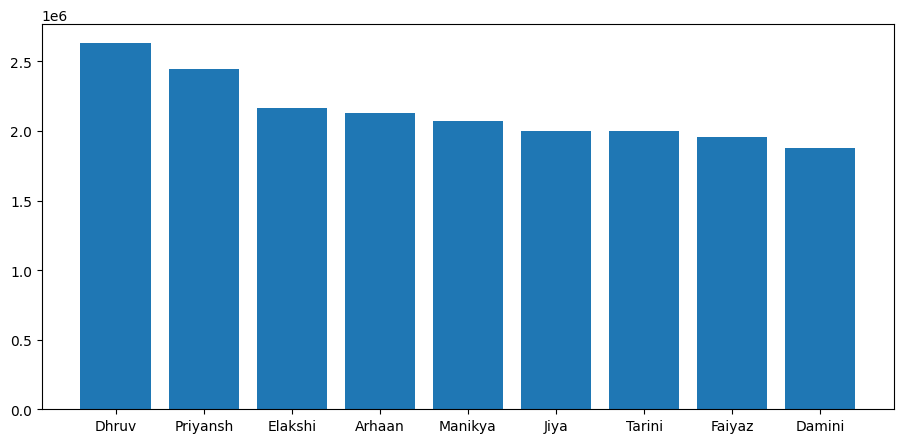

In [36]:
plt.figure(figsize=(11,5))
plt.bar(x = customer, height = expend)

In [7]:
query ="show tables;"
read_query(query)

,Tables_in_swiftmarket
0,categories
1,customers
2,employees
3,salesdata
4,subcategories
5,suppliers


In [8]:
query= "select * from employees limit 5;"
read_query(query)

,EmployeeID,FirstName,LastName,Email,Phone,Address,State,HireDate,Department,Salary
0,1001,Fateh,Roy,fname.lname@swiftm.org,+915182804115,H.No. 99\nMalhotra Circle,Bihar,2019-04-23,Marketing,54050.23
1,1002,Chirag,Balan,fname.lname@swiftm.org,06425511681,"91, Kalita",Chhattisgarh,2016-03-31,Legal,57094.43
2,1003,Dhanush,Lata,fname.lname@swiftm.org,+916818532690,H.No. 234\nLall,Bihar,2013-05-05,Accounts,40736.84
3,1004,Anika,Batta,fname.lname@swiftm.org,+914753170991,189\nThaker Zila,Arunachal Pradesh,2010-09-19,Legal,20412.30
4,1005,Keya,Dixit,fname.lname@swiftm.org,4791301806,"H.No. 42, Sachar",Manipur,2011-10-23,Logistics,49586.07


In [20]:
query = '''select fe.firstname, fe.lastname, fe.salary, fe.department
         from
         (select *, 
         rank() over(partition by department order by salary desc) as ranked
         from employees
         limit 50) fe
         
        where fe.ranked<=3'''

read_query (query)

,firstname,lastname,salary,department
0,Madhup,Vig,58979.77,Accounts
1,Heer,Kumar,54819.04,Accounts
2,Ishaan,Shanker,52132.21,Accounts
3,Kanav,Wali,59183.76,Analyst
4,Kanav,Ram,57531.39,Analyst
5,Yakshit,Kashyap,54538.61,Analyst
6,Azad,Chana,56174.11,Engineering
7,Armaan,Vohra,50539.38,Engineering
8,Shalv,Chanda,49662.63,Engineering
9,Rhea,Handa,56513.16,HR Admin


In [42]:
query = '''select fe.firstname, fe.lastname, fe.total_salary, fe.department, fe.ranked
         from
         (select *, 
         sum(salary) over(partition by department ) as total_salary,

         rank() over(partition by department order by salary desc) as ranked
         from employees
        limit 50) fe
         
        where fe.ranked < 2'''

emp_salary = read_query (query)

In [43]:
emp_salary["department"].values

<StringArray>
['Accounts', 'Analyst', 'Engineering', 'HR Admin']
Length: 4, dtype: str

In [48]:
dept_name =emp_salary["department"].values
emp_salary = emp_salary["total_salary"].values

In [49]:
emp_salary["total_salary"] = emp_salary["total_salary"].astype(float)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [32]:
emp_salary.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   firstname     12 non-null     str    
 1   lastname      12 non-null     str    
 2   total_salary  12 non-null     float64
 3   department    12 non-null     str    
 4   ranked        12 non-null     int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 612.0 bytes


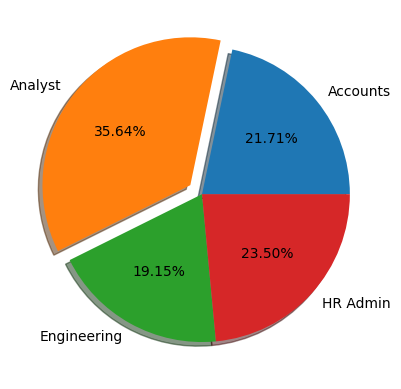

In [52]:
plt.pie(x= emp_salary, labels= dept_name,
        autopct= '%1.2f%%', explode =[0, 0.1,0,0],
        shadow= True)
plt.show()